In [ ]:
import pytest
import numpy as np
from numba import njit
import pandas as pd
import SRCG_utils as model_utils
import pickle
import sys

sys.path.append('../')
from scipy.optimize import minimize


class TestLogitFunction:
    def test_logit_midpoint(self):
        """Test logit at p=0.5 should be 0"""
        assert np.isclose(logit_1(0.5), 0.0)
    
    def test_logit_high_probability(self):
        """Test logit at high probability"""
        result = logit_1(0.9)
        assert result > 0
        assert np.isfinite(result)
    
    def test_logit_low_probability(self):
        """Test logit at low probability"""
        result = logit_1(0.1)
        assert result < 0
        assert np.isfinite(result)
    
    def test_logit_inverse(self):
        """Test that sigmoid and logit are inverses"""
        p = 0.7
        logit_p = logit_1(p)
        recovered = 1 / (1 + np.exp(-logit_p))
        assert np.isclose(p, recovered)


class TestGetValuesFromGraph:
    def test_empty_graph(self):
        """Test with zero graph (no connections)"""
        reward_list = np.array([1.0, 0.5, 0.0])
        graph = np.zeros((3, 3))
        values = get_values_from_graph_2_numba(reward_list, graph)
        assert len(values) == 3
        assert np.allclose(values, reward_list)
    
    def test_identity_graph(self):
        """Test with identity graph (self-loops only)"""
        reward_list = np.array([1.0, 0.5, 0.0])
        graph = np.eye(3)
        values = get_values_from_graph_2_numba(reward_list, graph)
        assert len(values) == 3
        # With identity, values should be 2*rewards (identity + identity)
        assert np.allclose(values, 2 * reward_list)
    
    def test_chain_graph(self):
        """Test with simple chain graph"""
        reward_list = np.array([0.0, 0.0, 1.0])
        graph = np.array([[0, 1, 0],
                          [0, 0, 1],
                          [0, 0, 0]], dtype=np.float64)
        values = get_values_from_graph_2_numba(reward_list, graph)
        assert len(values) == 3
        assert values[2] > 0  # Terminal state has reward
        assert values[0] > 0  # First state should propagate some reward


class TestLikelihoodFunction:
    def setup_method(self):
        """Create mock data for testing"""
        n_trials = 100
        self.free_choice = np.ones(n_trials, dtype=np.int64)
        self.transitions = np.random.randint(0, 2, n_trials, dtype=np.int64)
        self.choices = np.random.randint(0, 2, n_trials, dtype=np.int64)
        self.outcomes = np.random.randint(0, 2, n_trials, dtype=np.int64)
        self.second_steps = np.random.randint(0, 2, n_trials, dtype=np.int64)
        self.stims = np.zeros(n_trials, dtype=np.int64)
        self.n_episodes = np.array([n_trials], dtype=np.int64)
        
        self.subj_all = [
            self.free_choice,
            self.transitions,
            self.choices,
            self.outcomes,
            self.second_steps,
            self.stims,
            self.n_episodes
        ]
    
    def test_likelihood_returns_finite(self):
        """Test that likelihood returns finite value"""
        params = np.zeros(7)  # Neutral parameters
        nll = likelihood_term_nostim__freeFree_v3(params, self.subj_all)
        assert np.isfinite(nll)
        assert nll >= 0  # Negative log-likelihood should be non-negative
    
    def test_likelihood_different_params(self):
        """Test that different parameters give different likelihoods"""
        params1 = np.zeros(7)
        params2 = np.ones(7)
        
        nll1 = likelihood_term_nostim__freeFree_v3(params1, self.subj_all)
        nll2 = likelihood_term_nostim__freeFree_v3(params2, self.subj_all)
        
        assert nll1 != nll2
    
    def test_likelihood_extreme_temperature(self):
        """Test that extreme temperature values don't cause errors"""
        params_low_temp = np.array([0, 0, 0, 0, -10, 0, 0])  # Very low temp
        params_high_temp = np.array([0, 0, 0, 0, 5, 0, 0])   # High temp
        
        nll_low = likelihood_term_nostim__freeFree_v3(params_low_temp, self.subj_all)
        nll_high = likelihood_term_nostim__freeFree_v3(params_high_temp, self.subj_all)
        
        assert np.isfinite(nll_low)
        assert np.isfinite(nll_high)


class TestIntegration:
    def test_full_pipeline_mock_data(self):
        """Test the full pipeline with mock data"""
        # Create minimal mock session data
        n_trials = 50
        mock_data = pd.DataFrame({
            'free_choice': np.ones(n_trials),
            'transition': np.random.randint(0, 2, n_trials),
            'choice': np.random.randint(0, 2, n_trials),
            'outcome': np.random.randint(0, 2, n_trials),
            'second_step': np.random.randint(0, 2, n_trials),
            'stim': np.zeros(n_trials)
        })
        
        # Test that data can be processed
        assert len(mock_data) == n_trials
        assert 'choice' in mock_data.columns

In [ ]:
def logit_1(p):
    return np.log(p / (1 - p))
df_stim_opto = pd.read_pickle('../../BlancoPozos_two-step_dopamine-main/Data/df_stim_opto.pkl')


df_YFP = df_stim_opto[df_stim_opto['virus'] == 'YFP']

df_YFP_outcome_cue = df_YFP
df_YFP_subjectwise = {subject: df for subject, df in df_YFP_outcome_cue.groupby('subject')}

# subject_id = list(df_YFP_outcome_cue_subjectwise.keys())[0]
# session_df = df_YFP_outcome_cue_subjectwise[subject_id]

all_subject_items = []

for sid in df_YFP_subjectwise.keys():
# for sid in [71]:

    # df_YFP_sessionLv = df_YFP_subjectwise[71] # only load subject 71    
    df_YFP_sessionLv = df_YFP_subjectwise[sid] # only load subject 71    

    subject_items = []

    for j in range(len(df_YFP_sessionLv)):
        sess_num = pd.DataFrame.from_dict(
            df_YFP_sessionLv.iloc[j].sessions.trial_data
        ).apply(pd.to_numeric, errors='coerce').fillna(0)

        # try:
        #     sess_seed = seed_params[sid][j]
        #     print(f'Subject {sid}, Session {j}, Number of trials: {len(sess_num)}')
        # except:
        #     print(f'KeyError: Subject {sid} does not have session {j} in seed_params.')
        #     sess_seed = seed_params[sid][j-1]
        #     continue

        subject_items.append(sess_num )

    all_subject_items.append([sid, subject_items])


@njit
def get_values_from_graph_2_numba(reward_list, graph):
    n = len(reward_list)
    f_matrix = np.zeros((n, n))
    for i in range(4):
        # Numba-compatible matrix power and sum
        g_power = np.eye(n)
        for _ in range(i+1):
            g_power = g_power @ graph
        f_matrix += g_power
    for i in range(n):
        for j in range(n):
            if f_matrix[i, j] != 0:
                f_matrix[i, j] = 1
    for i in range(n):
        f_matrix[i, i] += 1  # add identity
    value_list = np.zeros(n)
    for i in range(n):
        for j in range(n):
            value_list[i] += f_matrix[i, j] * reward_list[j]
    return value_list

@njit
# stay bias parameter inside the logisitic
def likelihood_term_nostim__freeFree_v3(x, subj_all): 

    [free_choice, transitions, choices, outcomes, second_steps, stims, n_episodes] = subj_all
    
    # Use len() to get a proper integer for array initialization
    n_trials = len(free_choice)
    
    # x: [lr_base, lr_rew, discount, threshold, temperature, reward_learning_rate, staybias]
    states = ['right','left','up','down','up_reward','down_reward','no_reward']
    learning_rate = 1/(1 + np.exp(-x[0]))
    discount = 1/(1 + np.exp(-x[2]))
    threshold = 1/(1 + np.exp(-x[3]))
    reward_learning_rate = 1/(1 + np.exp(-x[5]))
    staybias = np.tanh(x[6])
    # forget = 1/(1 + np.exp(-x[7]))

    temperature = np.exp(x[4])
    if temperature < 1e-6:
        temperature = 1e-6
    given_rewards = np.array([0,0,0,0,1,1,0], dtype=np.float64)
    successor_representation = np.zeros((len(states),len(states)), dtype=np.float64)
    learned_rewards = np.zeros(len(states), dtype=np.float64)
    graph = np.zeros((len(states),len(states)), dtype=np.float64)
    choices_list = np.empty(n_trials, dtype=np.int32)
    choice_probs_list = np.empty(n_trials, dtype=np.float64)
    free_choice_list = np.empty(n_trials, dtype=np.int8)  # Use int8 instead of bool for numba


    lapse_rate = 0.00000000000000000001


    for i in range(n_trials):
        free_choice_trial = free_choice[i]
        choice = choices[i]
        outcome = outcomes[i]
        # transition = transitions[i]
        second_step = second_steps[i]
        current_state = 0 if choice == 0 else 1  # 0: right, 1: left
        # Use inlined get_values_from_graph_2 logic

        values = get_values_from_graph_2_numba(learned_rewards, graph)
        value_left = values[1]
        value_right = values[0]

        # Stay bias term: positive if previous choice was right (0), negative if left (1)
        # Only applies when i > 0
        prev_choice_idx = max(0, i - 1)
        prev_choice = choices[prev_choice_idx]
        has_prev = 1.0 * (i > 0)  # 1.0 if there's a previous trial, else 0.0

        stay_bias_term = has_prev * staybias * (1.0 - 2.0 * prev_choice)

        # Include stay bias in the value difference before the logistic
        
        value_diff = value_right - value_left + stay_bias_term 

        p_left = 1.0 / (1.0 + np.exp(value_diff / temperature))

        p_left = (1 - lapse_rate) * p_left + lapse_rate * 0.5

        choice_prob = p_left

        next_state = 3 if second_step == 0 else 2  # 3: down, 2: up
        state_number = current_state
        next_state_number = next_state
        td_error = np.eye(len(states))[next_state_number,:] - successor_representation[state_number,:] + discount * successor_representation[next_state_number,:]
        successor_representation[state_number,:] += learning_rate * td_error
        thresholded_successor = (successor_representation >= threshold).astype(np.float64)
        graph = thresholded_successor.copy()
        current_state = next_state
        # Only two cases for reward update: base or base+add_rew
        if outcome == 1:
            lr = x[0] + x[1]  # lr_base + add_rew
        else:
            lr = x[0]         # lr_base
        learning_rate_trial = 1/(1 + np.exp(-lr))

        # Determine next state based on outcome and second step
        if outcome == 1 and current_state == 2:
            next_state = 4  # up_reward
            # other_state = np.array([5], dtype=np.int64)


        elif outcome == 1 and current_state == 3:
            next_state = 5  # down_reward
            # other_state = np.array([4], dtype=np.int64)
        else:
            next_state = 6  # no_reward
            # other_state = np.array([4,5], dtype=np.int64)

        state_number = current_state
        next_state_number = next_state


        # Apply forgetting to all non-current reward states
        # for s in range(len(states)):
        #     if s in other_state:
        learned_rewards = learned_rewards * (1 - reward_learning_rate)

        # learned_rewards[next_state_number] = learned_rewards[next_state_number]*(1- reward_learning_rate) + reward_learning_rate*given_rewards[next_state_number]
        learned_rewards[next_state_number] = learned_rewards[next_state_number] + reward_learning_rate*given_rewards[next_state_number]


        td_error = np.eye(len(states))[next_state_number,:] - successor_representation[state_number,:] + discount * successor_representation[next_state_number,:]
        successor_representation[state_number,:] += learning_rate_trial * td_error
        thresholded_successor = (successor_representation >= threshold).astype(np.float64)
        graph = thresholded_successor.copy()
        choices_list[i] = choice
        choice_probs_list[i] = choice_prob
        free_choice_list[i] = int(free_choice_trial)  # Convert to int
        
    log_likelihood = 0.0
    for i in range(n_trials-1):# to avoid index error
        if free_choice_list[i] and free_choice_list[i+1]:
            choice = choices_list[i+1]
            choice_prob = choice_probs_list[i+1]
            if choice == 1:
                log_likelihood += np.log(choice_prob)
            else:
                log_likelihood += np.log(1 - choice_prob)

    
    # print('IT IS RUNNING LIKELIHOOD TERMS!!!!!1')

    return -log_likelihood


In [ ]:

# param_names_n = ['base', 'rew_bonus', 'discount', 'threshold', 'temperature', 'rew_learning_rate', 'stay_bias', 'forget']
param_names_n = ['base', 'rew_bonus', 'discount', 'threshold', 'temperature', 'rew_learning_rate', 'stay_bias']
params_subj = []

n_sample_fit = 20

In [ ]:
from joblib import Parallel, delayed
import numpy as np
from datetime import datetime
import time

# Replace the parallel fitting section with joblib

def fit_sample(args):
    """Wrapper for single sample optimization"""
    sample, n_variable, initial, subj_all, i,j = args
    
    free_choice, transitions, choices, outcomes, second_steps, stims, n_episodes = model_utils.import_data(subj_all)
    free_choice = free_choice.to_numpy().astype(np.int64)
    transitions = transitions.to_numpy().astype(np.int64)
    choices = choices.to_numpy().astype(np.int64)
    outcomes = outcomes.to_numpy().astype(np.int64)
    second_steps = second_steps.to_numpy().astype(np.int64)
    stims = stims.to_numpy().astype(np.int64)
    n_episodes = np.array([n_episodes], dtype=np.int64)
    
    if sample % 100 == 0:
        print(f"  Subject {i}: Running sample {sample}/1000")
    
    result = minimize(lambda x: likelihood_term_nostim__freeFree_v3(x, [free_choice, transitions, choices, outcomes, second_steps, stims, n_episodes]), 
                     initial, method='Nelder-Mead')
    return result.x, result.fun


def fit_session(args):
    """Fit a single session using joblib for parallel samples"""
    i, j, subj_all = args
    n_variable = len(param_names_n)
    n_sample = n_sample_fit
    
    print(f"\n{'='*60}")
    print(f"Starting Subject {i} - Running {n_sample} optimization samples...")
    print(f"{'='*60}")
    start_time = time.time()
    
    # Prepare sample arguments
    sample_args = []
    for sample in range(n_sample):
        n_samples = 1
        samples_without_temp = np.random.uniform(0.01, 0.99, size=(n_samples, 5))
        samples_without_temp_transformed = logit_1(samples_without_temp)
        stay_samples_transformed = np.arctanh(np.random.uniform(-0.99, 0.99, size=(n_samples, 1)))
        temp_samples = np.random.uniform(0.001, 5.0, size=(n_samples, 1))
        temp_samples_transformed = np.log(temp_samples)
        x0 = np.hstack((samples_without_temp_transformed[:, :5],
                       temp_samples_transformed,
                       samples_without_temp_transformed[:, 5:],
                       stay_samples_transformed))
                    #    stay_samples_transformed,
                    #    samples_without_temp_transformed[:, 6:]))
        initial = x0[0]
        
        sample_args.append((sample, n_variable, initial, subj_all, i,j))
    
    # Use joblib for parallel execution with progress tracking
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(fit_sample)(args) for args in sample_args
    )
    
    y = np.zeros((n_sample, n_variable))
    fval = np.zeros(n_sample)
    
    for sample, (x, fun) in enumerate(results):
        y[sample, :] = x
        fval[sample] = fun
    
    best = y[np.argmin(fval)]
    elapsed_time = time.time() - start_time
    
    print(f"\nSubject {i} Session {j} - Completed in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
    
    transformed_params = np.hstack((
        1/(1+np.exp(-best[:4])),
        np.exp(best[4]),
        1/(1+np.exp(-best[5])),
        np.tanh(best[6])
        # 1/(1+np.exp(-best[7])),

    ))
    
    likelihood = np.min(fval)
    k = len(best)
    n = len(subj_all)
    ll_max = likelihood
    bic = k * np.log(n) - 2 * ll_max
    
    return [i, j, best, transformed_params, likelihood, bic]




In [ ]:

# Main execution with joblib
# tasks = []
# for i in list(df_YFP_subjectwise.keys()):
#     # subj_sessions_list = df_YFP_subjectwise[i]['sessions'].tolist()
#     subj_sessions_list = df_YFP_subjectwise[i].loc[df_YFP_subjectwise[i]['stim_type']=='outcome_cue']['sessions'].tolist()
#     subj_sessions_list = [pd.DataFrame.from_dict(session.trial_data) for session in subj_sessions_list]
#     subj_all = pd.concat(subj_sessions_list, ignore_index=True)

#     # Replace 'NaN' in stim  for 0, but the line 
    
#     # Convert to numeric, coercing any remaining non-numeric values to NaN
#     subj_all['stim'] = pd.to_numeric(subj_all['stim'], errors='coerce').fillna(0).astype(np.int64)
    
#     tasks.append((i, subj_all))



tasks = []
for i in list(df_YFP_subjectwise.keys()):
    subj_sessions_list = df_YFP_subjectwise[i]['sessions'].tolist()
    subj_sessions_list = [pd.DataFrame.from_dict(session.trial_data) for session in subj_sessions_list]
    for j in range(len(subj_sessions_list)):
        subj_all = subj_sessions_list[j]

        # Convert to numeric, coercing any remaining non-numeric values to NaN
        subj_all['stim'] = pd.to_numeric(subj_all['stim'], errors='coerce').fillna(0).astype(np.int64)

        tasks.append((i, j, subj_all))



print(f"\n{'#'*70}")
print(f"# STARTING PARALLEL FITTING PIPELINE WITH JOBLIB")
print(f"# Total sessions to fit: {len(tasks)}")
print(f"# Using all available CPU cores")
print(f"# {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'#'*70}\n")

overall_start = time.time()

# Use joblib for session-level parallelization
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(fit_session)(task) for task in tasks
)

overall_elapsed = time.time() - overall_start

print(f"\n{'#'*70}")
print(f"# FITTING COMPLETE!")
print(f"# Total time: {overall_elapsed:.2f} seconds ({overall_elapsed/60:.2f} minutes)")
print(f"# Sessions completed: {len(results)}")
print(f"# {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'#'*70}\n")

params_subj.extend(results)


######################################################################
# STARTING PARALLEL FITTING PIPELINE WITH JOBLIB
# Total sessions to fit: 194
# Using all available CPU cores
# 2026-02-05 10:57:01
######################################################################



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.


In [ ]:

# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# output_filename = f'YFP_pooledAlll_free+_forget&stay_sess4seeds_fit_results_{n_sample_fit}_{timestamp}.pkl'
# with open(output_filename, 'wb') as f:
#     pickle.dump(params_subj, f)


In [ ]:
# with open('YFP_pooledAlll_free+_forget&stay_sess4seeds_fit_results_20_20260129_163656.pkl', 'rb') as f:
#     params_subj = pickle.load(f)

In [6]:
# ...existing code...
# Build a DataFrame from params_subj
records = []
for entry in params_subj:
    subj_id, sess_j, best, transformed, likelihood, bic = entry
    rec = {
        'subject': subj_id,
        'session': sess_j,
        'likelihood': likelihood,
        'bic': bic,
        'raw_params': np.array(best, dtype=float),
        'transformed_params': np.array(transformed, dtype=float),
    }
    # split into named columns
    for name, raw_val, tr_val in zip(param_names_n, best, transformed):
        rec[f'raw_{name}'] = raw_val
        rec[name] = tr_val
    records.append(rec)

df_params = pd.DataFrame(records).sort_values('subject').reset_index(drop=True)
df_params['rew_bonus_trans'] =  1/(1+np.exp(-((df_params['raw_base'] + df_params['raw_rew_bonus'] ).values )))
df_params
# ...existing code...

,subject,session,likelihood,bic,raw_params,transformed_params,raw_base,base,raw_rew_bonus,rew_bonus,...,discount,raw_threshold,threshold,raw_temperature,temperature,raw_rew_learning_rate,rew_learning_rate,raw_stay_bias,stay_bias,rew_bonus_trans
0,63,0,66.968447,-96.848672,"[3.566125438899655, -3.179294944001194, -0.316...","[0.9725118013762518, 0.03995236843527466, 0.42...",3.566125,0.972512,-3.179295,0.039952,...,0.421489,3.593446,0.973233,-0.295536,0.744132,-1.530041,0.177988,0.547992,0.499014,0.595519
1,63,22,62.405462,-83.608195,"[0.12676964539713884, 13.622441380613969, 9.22...","[0.5316500365915874, 0.9999987870347709, 0.999...",0.126770,0.531650,13.622441,0.999999,...,0.999901,0.829204,0.696187,-1.647899,0.192454,-1.957330,0.123756,0.368840,0.352976,0.999999
2,63,23,41.041216,-40.650176,"[-1.9650319604014872, 1.8659282957527537, -7.7...","[0.12292350503443548, 0.8659864439890652, 0.00...",-1.965032,0.122924,1.865928,0.865986,...,0.000452,0.749880,0.679153,-0.843055,0.430394,10.379436,0.999969,16.961487,1.000000,0.475244
3,63,24,107.311745,-172.047957,"[-1.329029402430618, 1.9297212268166435, 0.038...","[0.2093199587526643, 0.8732185606933857, 0.509...",-1.329029,0.209320,1.929721,0.873219,...,0.509577,0.666604,0.660742,-0.964489,0.381178,1.286606,0.783572,0.466259,0.435172,0.645815
4,63,25,73.511545,-105.013187,"[-1.7644742643208153, 1.8941105649427912, 2.19...","[0.1462308549188489, 0.8692235045292065, 0.899...",-1.764474,0.146231,1.894111,0.869224,...,0.899396,0.130272,0.532522,-1.395295,0.247760,-0.012264,0.496934,0.254844,0.249467,0.532364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,75,14,85.191755,-129.318235,"[-0.09505006018595494, 0.15478520024033504, -1...","[0.4762553590364423, 0.5386192260715448, 0.193...",-0.095050,0.476255,0.154785,0.538619,...,0.193753,0.094931,0.523715,-1.355153,0.257908,-0.236992,0.441028,0.165636,0.164138,0.514929
190,75,15,124.574621,-207.053235,"[-1.100740996668733, 0.06925544901765032, 0.00...","[0.2496010796967323, 0.5173069453406606, 0.500...",-1.100741,0.249601,0.069255,0.517307,...,0.500418,0.363166,0.589807,-0.653810,0.520061,-0.014867,0.496283,0.486844,0.451708,0.262796
191,75,16,71.810057,-103.396692,"[-2.2168509358062876, 0.3552800164176316, -4.6...","[0.09824744252206426, 0.5878973808635416, 0.00...",-2.216851,0.098247,0.355280,0.587897,...,0.009880,-0.858123,0.297732,-1.515079,0.219791,0.722107,0.673071,0.280170,0.273062,0.134520
192,75,18,123.996814,-206.675194,"[-1.911879511345747, 2.3906932545824056, 20.78...","[0.12876984603917138, 0.9161148589954937, 0.99...",-1.911880,0.128770,2.390693,0.916115,...,1.000000,0.372323,0.592020,-0.685545,0.503816,0.222921,0.555501,0.161428,0.160040,0.617468


In [8]:
params1 = df_params.raw_params.tolist()

In [ ]:
def sims_term_nostim_v2(x, free_choice, transitions, choices, outcomes, second_steps, stims, n_episodes):
    # x: [lr_base, lr_rew, discount, threshold, temperature, reward_learning_rate, staybias]
    states = ['right','left','up','down','up_reward','down_reward','no_reward']
    learning_rate = 1/(1 + np.exp(-x[0]))
    discount = 1/(1 + np.exp(-x[2]))
    threshold = 1/(1 + np.exp(-x[3]))
    reward_learning_rate = 1/(1 + np.exp(-x[5]))
    staybias = np.tanh(x[6])
    # forget = 1/(1 + np.exp(-x[7]))

    temperature = np.exp(x[4])
    if temperature < 1e-6:
        temperature = 1e-6
    given_rewards = np.array([0,0,0,0,1,1,0], dtype=np.float64)

    successor_representation = np.zeros((len(states),len(states)), dtype=np.float64)
    learned_rewards = np.zeros(len(states), dtype=np.float64)
    graph = np.zeros((len(states),len(states)), dtype=np.float64)

    choices_list = np.empty(n_episodes, dtype=np.int32)
    choice_probs_list = np.empty(n_episodes, dtype=np.float64)
    outcome_list = np.empty(n_episodes, dtype=np.int32)
    free_choice_list = np.empty(n_episodes, dtype=np.bool_)
    transition_list = np.empty(n_episodes, dtype=np.int32)
    second_steps_list = np.empty(n_episodes, dtype=np.int32)
    stims_list = np.empty(n_episodes, dtype=np.int32)
    simulated_choices_list = np.empty(n_episodes, dtype=np.int32)
    graph_list = []

    lapse_rate = 0.00000000000000000001


    for i in range(n_episodes):
        free_choice_trial = free_choice[i]
        choice = choices[i]
        outcome = outcomes[i]
        transition = transitions[i]
        second_step = second_steps[i]
        current_state = 0 if choice == 0 else 1  # 0: right, 1: left
        # Use inlined get_values_from_graph_2 logic
        values = get_values_from_graph_2_numba(learned_rewards, graph)
        value_left = values[1]
        value_right = values[0]

        # # Stay bias term: positive if previous choice was right (0), negative if left (1)
        # # Only applies when i > 1

        prev_choice_idx = max(0, i - 1)
        prev_choice = choices[prev_choice_idx]
        has_prev = 1.0 * (i > 0)  # 1.0 if there's a previous trial, else 0.0

        stay_bias_term = has_prev * staybias * (1.0 - 2.0 * prev_choice)



        # Include stay bias in the value difference before the logistic
        value_diff = value_right - value_left + stay_bias_term
        p_left = 1.0 / (1.0 + np.exp(value_diff / temperature))

        p_left = (1 - lapse_rate) * p_left + lapse_rate * 0.5

        choice_prob = p_left

        # run simulation choice
        simulated_choice = np.random.choice([0, 1], p=[1- choice_prob,choice_prob])


        next_state = 3 if second_step == 0 else 2  # 3: down, 2: up
        state_number = current_state
        next_state_number = next_state
        td_error = np.eye(len(states))[next_state_number,:] - successor_representation[state_number,:] + discount * successor_representation[next_state_number,:]
        successor_representation[state_number,:] += learning_rate * td_error
        thresholded_successor = (successor_representation >= threshold).astype(np.float64)
        graph = thresholded_successor.copy()
        current_state = next_state


        # Only two cases for reward update: base or base+add_rew
        if outcome == 1:
            lr = x[0] + x[1]  # lr_base + add_rew
        else:
            lr = x[0]         # lr_base
        learning_rate_trial = 1/(1 + np.exp(-lr))
        # Determine next state based on outcome and second step
        if outcome == 1 and current_state == 2:
            next_state = 4  # up_reward
            # other_state = np.array([5], dtype=np.int64)


        elif outcome == 1 and current_state == 3:
            next_state = 5  # down_reward
            # other_state = np.array([4], dtype=np.int64)
        else:
            next_state = 6  # no_reward
            # other_state = np.array([4,5], dtype=np.int64)

        state_number = current_state
        next_state_number = next_state


        # Apply forgetting to all non-current reward states

        learned_rewards = learned_rewards * (1 - reward_learning_rate)

        # learned_rewards[next_state_number] = learned_rewards[next_state_number]*(1- reward_learning_rate) + reward_learning_rate*given_rewards[next_state_number]
        learned_rewards[next_state_number] = learned_rewards[next_state_number] + reward_learning_rate*given_rewards[next_state_number]



        
        td_error = np.eye(len(states))[next_state_number,:] - successor_representation[state_number,:] + discount * successor_representation[next_state_number,:]
        successor_representation[state_number,:] += learning_rate_trial * td_error
        thresholded_successor = (successor_representation >= threshold).astype(np.float64)
        graph = thresholded_successor.copy()
        choices_list[i] = choice
        choice_probs_list[i] = choice_prob
        simulated_choices_list[i] = simulated_choice
        outcome_list[i] = outcome
        free_choice_list[i] = free_choice_trial
        transition_list[i] = transition
        second_steps_list[i] = second_step
        graph_list.append(graph.copy())
        # stims_list[i] = stim_trial  


    df_out = pd.DataFrame({
        'choices': choices_list,
        'choice_probs': choice_probs_list,
        'free_choice': free_choice_list,
        'outcomes': outcome_list,
        # 'stim': stims_list,
        'second_steps': second_steps_list,
        'transitions': transition_list,
        'simulated_choices': simulated_choices_list,
        'graphs': graph_list
    })
    return df_out

In [13]:
def fourBars(results, trans_state = 1):
    outDF = results.copy()
    # add column stay next
    outDF['stay'] = outDF['choices'].shift(-1) == outDF['choices']
    
    outDF['free_next'] =  (outDF['free_choice'].shift(-1) == True).values
    outDF = outDF.loc[(outDF['free_choice'] == True) & (outDF['free_next'] == True)]


    if trans_state == 1:
        RR =   outDF.loc[(outDF['transitions']== 0) & (outDF['outcomes']== 1) ]
        RN =   outDF.loc[(outDF['transitions']== 0) & (outDF['outcomes']== 0) ]
        CR =   outDF.loc[(outDF['transitions']== 1) & (outDF['outcomes']== 1) ]
        CN =   outDF.loc[(outDF['transitions']== 1) & (outDF['outcomes']== 0) ]
    else:
        RR =   outDF.loc[(outDF['transitions']== 1) & (outDF['outcomes']== 1) ]
        RN =   outDF.loc[(outDF['transitions']== 1) & (outDF['outcomes']== 0) ]
        CR =   outDF.loc[(outDF['transitions']== 0) & (outDF['outcomes']== 1) ]
        CN =   outDF.loc[(outDF['transitions']== 0) & (outDF['outcomes']== 0) ] 
        

    # print('4 bar graph for this animal')
    print('Common Reward', CR['stay'].mean())
    print('Rare Reward', RR['stay'].mean())
    print('Common No Reward', CN['stay'].mean())
    print('Rare No Reward', RN['stay'].mean())

    return[CR['stay'].mean(), RR['stay'].mean(), CN['stay'].mean(), RN['stay'].mean()]


def fourBars_sims_choProb(results, trans_state = 1):
    print("Calculating four bars based on simulated choice probabilities")

    outDF = results.copy()
    # add column stay next
    outDF['stay'] = outDF['choices'].shift(-1) == outDF['choices']
    

    # estimate probabilty of staying based on choice_probs and previous choices   
    # for j in outDF.index:
    #     if j >= len(outDF.index) - 1:
    #         outDF.at[j, 'stay_prob_sims'] = np.nan
    #     else:
    #         if outDF.at[j+1, 'choices'] == 1: # if previous choice is left
    #             outDF.at[j, 'stay_prob_sims'] = (outDF.at[j, 'choice_probs'])
    #         else: # if previous choice is right
    #             outDF.at[j, 'stay_prob_sims'] = (1 - outDF.at[j, 'choice_probs'])
    for j in outDF.index:
        if j >= len(outDF.index) - 1:
            outDF.at[j, 'stay_prob_sims'] = np.nan
        else:
            if outDF.at[j, 'choices'] == 1: # if previous choice is left
                outDF.at[j, 'stay_prob_sims'] = (outDF.at[j+1, 'choice_probs'])
            else: # if previous choice is right
                outDF.at[j, 'stay_prob_sims'] = (1 - outDF.at[j+1, 'choice_probs'])


    # keep only free choices

    outDF['free_next'] =  (outDF['free_choice'].shift(-1) == True).values
    outDF = outDF.loc[(outDF['free_choice'] == True) & (outDF['free_next'] == True)]

    if trans_state == 1:
        RR =   outDF.loc[(outDF['transitions']== 0) & (outDF['outcomes']== 1) ]
        RN =   outDF.loc[(outDF['transitions']== 0) & (outDF['outcomes']== 0) ]
        CR =   outDF.loc[(outDF['transitions']== 1) & (outDF['outcomes']== 1) ]
        CN =   outDF.loc[(outDF['transitions']== 1) & (outDF['outcomes']== 0) ]
    else:
        RR =   outDF.loc[(outDF['transitions']== 1) & (outDF['outcomes']== 1) ]
        RN =   outDF.loc[(outDF['transitions']== 1) & (outDF['outcomes']== 0) ]
        CR =   outDF.loc[(outDF['transitions']== 0) & (outDF['outcomes']== 1) ]
        CN =   outDF.loc[(outDF['transitions']== 0) & (outDF['outcomes']== 0) ] 
        

    print('4 bar graph for this animal (simulations)')
    print('Common Reward', CR['stay_prob_sims'].mean())
    print('Rare Reward', RR['stay_prob_sims'].mean())
    print('Common No Reward', CN['stay_prob_sims'].mean())
    print('Rare No Reward', RN['stay_prob_sims'].mean())

    return[CR['stay_prob_sims'].mean(), RR['stay_prob_sims'].mean(), CN['stay_prob_sims'].mean(), RN['stay_prob_sims'].mean()]




In [ ]:

tasks_with_trans = []
for i in list(df_YFP_subjectwise.keys()):
    subj_sessions_list = df_YFP_subjectwise[i]['sessions'].tolist()
    subj_sessions_list = [pd.DataFrame.from_dict(session.trial_data) for session in subj_sessions_list]
    subj_all = pd.concat(subj_sessions_list, ignore_index=True)
    trans_state = np.unique(df_YFP_subjectwise[i].sessions.tolist()[0].blocks['trial_trans_state'])[0]


    for j in range(len(subj_sessions_list)):
        subj_all = subj_sessions_list[j]

        # Convert to numeric, coercing any remaining non-numeric values to NaN
        subj_all['stim'] = pd.to_numeric(subj_all['stim'], errors='coerce').fillna(0).astype(np.int64)

        tasks_with_trans.append((i, j, subj_all,trans_state))


In [15]:
import matplotlib.pyplot as plt

In [16]:
def plot_4_bars(bars1, bars2, labels = ['','']):
    plt.figure(figsize=(10,5))

    fig, ax = plt.subplots()
    x = np.array(range(4))  # the label locations

    width = 0.35  # the width of the bars
    x_ = width/2
    ax.bar(x - x_, bars1,  label = labels[0], width=width)
    ax.bar(x + x_, bars2,  label = labels[1], width=width)
# 
    ax.set_ylabel('Stay Probability')
    ax.set_title('Stay Probability by Transition and Outcome')
    ax.set_xticks(x)
    plt.ylim(0,1)
    #horixontal line at y = 0.5 
    plt.axhline(0.5, color='black', linestyle='--')
    ax.legend()


# show by participant

In [43]:
# Main execution with joblib
tasks_with_trans_by_session = []


for i in list(df_YFP_subjectwise.keys()):
    # subj_sessions_list = df_YFP_subjectwise[i].loc[df_YFP_subjectwise[i]['stim_type']=='outcome_cue']['sessions'].tolist()
    # subj_trials_list = df_YFP_subjectwise[i].loc[df_YFP_subjectwise[i]['stim_type']=='outcome_cue']['sessions'].tolist()

    subj_sessions_list = df_YFP_subjectwise[i]['sessions'].tolist()
    subj_trials_list = df_YFP_subjectwise[i]['sessions'].tolist()


    subj_sessions_list_trials = [pd.DataFrame.from_dict(session.trial_data) for session in subj_sessions_list]
    # subj_all = pd.concat(subj_sessions_list_trials , ignore_index=True)

    trans_rew_list = [session.blocks['trial_rew_state'] for session in subj_trials_list]
    # trans_rew_list = np.concatenate(trans_rew_list)


    j_count = 0

    for j in range(len(subj_sessions_list_trials)):

        subj_sess = subj_sessions_list_trials[j]
        trans_rew_sess_list = trans_rew_list[j]

        subj_sess['trial_rew_state'] = trans_rew_sess_list.copy()

        trans_state = np.unique(df_YFP_subjectwise[i].sessions.tolist()[0].blocks['trial_trans_state'])[0]


        if len(subj_sess) > 200:
        # Replace 'NaN' in stim  for 0, but the line

            # Convert to numeric, coercing any remaining non-numeric values to NaN
            subj_sess['stim'] = pd.to_numeric(subj_sess['stim'], errors='coerce').fillna(0).astype(np.int64)
            tasks_with_trans_by_session.append((i,j_count, subj_sess,trans_state))
            j_count  = j_count + 1


In [62]:
def plot_simulations_agents_by_sess(
    params_by_sess_df,
    tasks_with_trans_by_session,
    n_repeats=20,
    plotOn=0
):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt




    # -----------------------------
    # Containers for bar values
    # -----------------------------
    barsData = []
    barsSims = []
    barsSubj = []
    graphs_lists_sims = []

    c = -1
    for i, j in [x[0:2] for x in tasks_with_trans_by_session]:
        c += 1

        print(f'Simulating Subject {i} - Session {j}')

        x_in = params_by_sess_df.loc[
            (params_by_sess_df['subject'] == i) &
            (params_by_sess_df['session'] == j),
            'raw_params'
        ].values[0]

        for r in range(n_repeats):

            (
                free_choice_in,
                transitions_in,
                choices_in,
                outcomes_in,
                second_steps_in,
                stims_in,
                n_episodes_in
            ) = model_utils.import_data(tasks_with_trans_by_session[c][2])

            rew_blocks_in = tasks_with_trans_by_session[c][2].trial_rew_state
            trans_state_in = tasks_with_trans_by_session[c][-1]

            df_sims_out = sims_term_nostim_v2(
                x_in,
                free_choice_in,
                transitions_in,
                choices_in,
                outcomes_in,
                second_steps_in,
                stims_in,
                n_episodes_in,
                # rew_blocks_in,
                # trans_state_in
            )

            if plotOn == 1:
                plt.figure(figsize=(20, 3))
                plt.plot(df_sims_out.choice_probs.rolling(4).mean()[1000:1500],
                         color='blue', label='sims Prob')
                plt.plot(df_sims_out.simulated_choices.rolling(4).mean()[1000:1500],
                         color='green', label='sims Cho')
                plt.plot(df_sims_out.choices_og.rolling(4).mean()[1000:1500],
                         color='red', label='animal')
                plt.legend()
                plt.show()

            # ---- compute 4-bar summaries ----
            barsStimData = fourBars(df_sims_out, trans_state=trans_state_in)
            barsStimSims = fourBars_sims_choProb(df_sims_out, trans_state=trans_state_in)

            if plotOn == 1:
                plot_4_bars(barsStimData, barsStimSims, labels=['data', 'sims'])

            barsSubj.append(i)
            barsData.append(barsStimData)
            barsSims.append(barsStimSims)


            graphs_lists_sims.append(df_sims_out.graphs.values[50:]) # ignore the first 50 trials, to get stable graphs


    # -----------------------------
    # Build dataframe
    # -----------------------------
    dataBars = pd.DataFrame({
        'subj': barsSubj,
        'data': barsData,
        'sims': barsSims
    })

    # -----------------------------
    # SUBJECT-LEVEL AVERAGING
    # -----------------------------
    subj_means = (
        dataBars
        .groupby('subj')
        .agg({
            'data': lambda x: np.mean(np.stack(x), axis=0),
            'sims': lambda x: np.mean(np.stack(x), axis=0)
        })
    )

    # -----------------------------
    # GROUP MEAN + SEM
    # -----------------------------
    data_stack = np.stack(subj_means['data'].values)
    sims_stack = np.stack(subj_means['sims'].values)

    print(data_stack)
    print(sims_stack)

    mean_barsData = data_stack.mean(axis=0)
    mean_barsSims = sims_stack.mean(axis=0)

    n_subj = data_stack.shape[0]

    sterro_barsData = data_stack.std(axis=0, ddof=1) / np.sqrt(n_subj)
    sterro_barsSims = sims_stack.std(axis=0, ddof=1) / np.sqrt(n_subj)

    # -----------------------------
    # PLOTTING
    # -----------------------------
    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(4)
    width = 0.35
    x_ = width / 2

    ax.bar(x - x_, mean_barsData,
           yerr=sterro_barsData,
           label='Data',
           width=width)

    ax.bar(x + x_, mean_barsSims,
           yerr=sterro_barsSims,
           label='Simulations',
           width=width)

    ax.set_ylabel('Stay Probability')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='black', linestyle='--')

    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Common Reward', 'Rare Reward',
         'Common No Reward', 'Rare No Reward'],
        rotation=45
    )

    ax.set_title('Subjects – Stay Probability (subject-averaged)')
    ax.legend()

    plt.tight_layout()
    plt.show()



   # plot only data

   # Generate 4 bard graphs with error bars

    mean_values = mean_barsData
    sem_values = sterro_barsData
    n = mean_barsData.shape[0]
    plt.figure(figsize=(6, 6))


    palette = {
        'CR': 'b',  # blue
        'CU': 'b',  # blue
        'RR': 'r',  # orange
        'RU': 'r'   # orange
    }




    plt.bar(['R1', 'R2', 'R3', 'R4'], mean_values, yerr=sem_values, capsize=5, color=[palette['CR'], palette['RR'], palette['CU'], palette['RU']])
    # add error bars
    plt.errorbar(['R1', 'R2', 'R3', 'R4'], mean_values, yerr=sem_values, fmt='none', ecolor='black', capsize=5)

    plt.ylim(0, 1)
    plt.ylabel('P(Stay)', fontsize=20)
    # plt.title('Model Stay Probability with Error Bars', fontsize=16)

    plt.ylim(0, 1)
    plt.title('Data', fontsize=16)

    # remove ticks x and y axis
    plt.xticks([],fontsize=16)
    plt.yticks(fontsize=25)

    # add horizontal line
    plt.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5)

    sns.despine()

    # to figure to file svg
    plt.savefig('Figures/mouse2step_behavior_data_forget&stay.svg')
    plt.show()
        

   # plot only sims

   # Generate 4 bard graphs with error bars

    mean_values = mean_barsSims
    sem_values = sterro_barsSims
    n = mean_barsData.shape[0]
    plt.figure(figsize=(6, 6))


    palette = {
        'CR': 'b',  # blue
        'CU': 'b',  # blue
        'RR': 'r',  # orange
        'RU': 'r'   # orange
    }

    plt.bar(['R1', 'R2', 'R3', 'R4'], mean_values, yerr=sem_values, capsize=5, color=[palette['CR'], palette['RR'], palette['CU'], palette['RU']])
    # add error bars
    plt.errorbar(['R1', 'R2', 'R3', 'R4'], mean_values, yerr=sem_values, fmt='none', ecolor='black', capsize=5)

    plt.ylim(0, 1)
    plt.ylabel('P(Stay)', fontsize=20)
    # plt.title('Model Stay Probability with Error Bars', fontsize=16)


    plt.ylim(0, 1)
    plt.title('Sims', fontsize=16)

    plt.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5)

    # remove ticks x and y axis
    plt.xticks([],fontsize=16)
    plt.yticks(fontsize=25)

    sns.despine()

    # to figure to file svg
    plt.savefig('Figures/mouse2step_behavior_sims_forget&stay.svg')

    plt.show()

    return subj_means,graphs_lists_sims


Simulating Subject 63 - Session 0
Common Reward 0.7540983606557377
Rare Reward 0.4166666666666667
Common No Reward 0.75
Rare No Reward 0.35714285714285715
Calculating four bars based on simulated choice probabilities
4 bar graph for this animal (simulations)
Common Reward 0.727261374813866
Rare Reward 0.6341532581493127
Common No Reward 0.6438506167068608
Rare No Reward 0.6530163779680188
Simulating Subject 63 - Session 1
Common Reward 0.8805970149253731
Rare Reward 0.23076923076923078
Common No Reward 0.7083333333333334
Rare No Reward 0.631578947368421
Calculating four bars based on simulated choice probabilities
4 bar graph for this animal (simulations)
Common Reward 0.6882126569479011
Rare Reward 0.6209711477484408
Common No Reward 0.6377912683050169
Rare No Reward 0.6426343293275335
Simulating Subject 63 - Session 2
Common Reward 0.9565217391304348
Rare Reward 0.7
Common No Reward 0.7368421052631579
Rare No Reward 0.76
Calculating four bars based on simulated choice probabilities
4

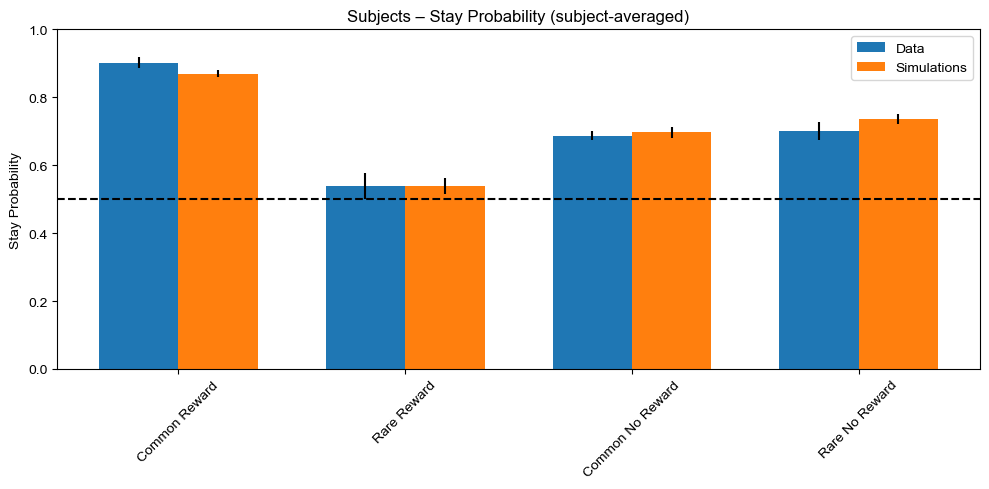

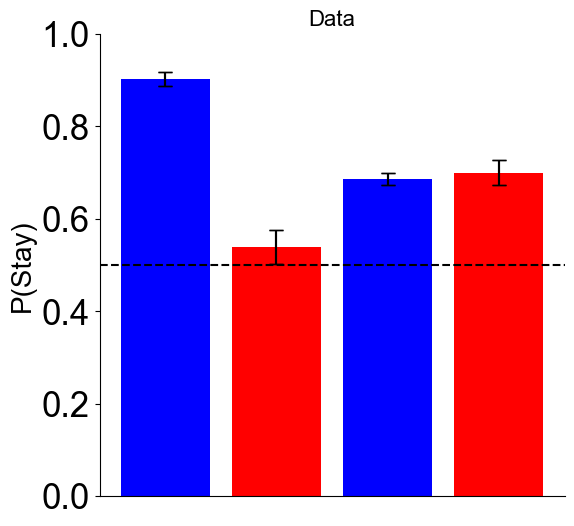

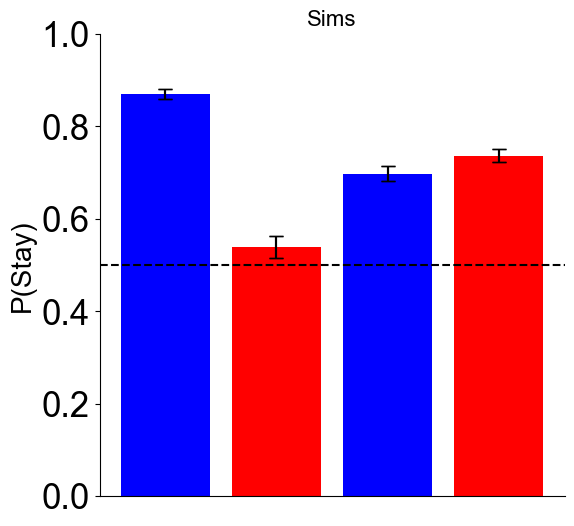

In [65]:
subj_means,graphs_lists_sims = plot_simulations_agents_by_sess(df_params,tasks_with_trans_by_session,n_repeats = 1, plotOn = 0)